<img style="float: left; margin: 30px 15px 15px 15px;" src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="500" height="250" /> 
    
    
# <font color='navy'> Modelo de Puntuación Crediticia

<font color='black'>

- Ivanna herrera Ibarra
- Ana Sofía Hinojosa Bale
- Luis Fernando Márquez Bañuelos

## <font color='royalblue'> Librerías

In [1]:
import shap
import optuna
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier, plot_importance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

## <font color='royalblue'> Benchmark

In [2]:
data = pd.read_csv('clean_train.csv')

data['Credit_Score'] = data['Credit_Score'].map({'Poor': 0, 'Standard': 1, 'Good': 2})
data = data.select_dtypes(include=['float64', 'int64', 'bool'])

target = 'Credit_Score'

In [3]:
X = data.copy()
X = X.drop(columns=[target])
y = data[target]

In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

              precision    recall  f1-score   support

           0       0.51      0.55      0.53      5799
           1       0.57      0.74      0.65     10635
           2       0.00      0.00      0.00      3566

    accuracy                           0.55     20000
   macro avg       0.36      0.43      0.39     20000
weighted avg       0.45      0.55      0.50     20000



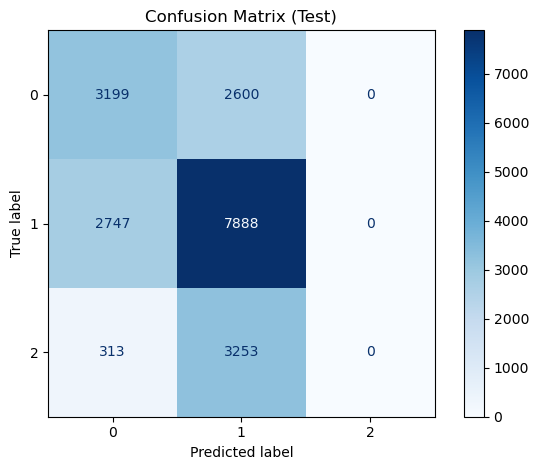

In [5]:
# Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=[0, 1, 2],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

## <font color='royalblue'> Feature Selection

              precision    recall  f1-score   support

           0       0.77      0.69      0.73      5799
           1       0.74      0.80      0.77     10635
           2       0.64      0.59      0.62      3566

    accuracy                           0.73     20000
   macro avg       0.72      0.70      0.71     20000
weighted avg       0.73      0.73      0.73     20000



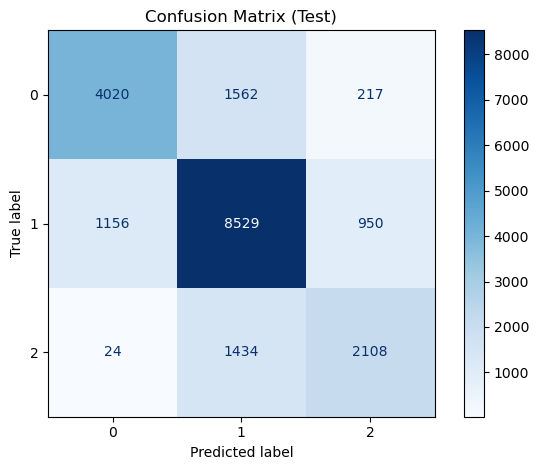

In [6]:
# We use a XGBoost model because is the most powerful model you can throw a this problem. This is mainly to help with determining the variable importance and 
# the weights for the credit score, but we also evaluate its performance to have a reference of how good the credit score can be.
model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=500,
    max_depth=8,
    learning_rate=0.01,
    min_child_weight=3,
    subsample=0.6,
    colsample_bytree=0.6,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=0
)

y_pred_xgb = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred_xgb))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=[0, 1, 2],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

### <font color = 'skyblue'> Feature Importance

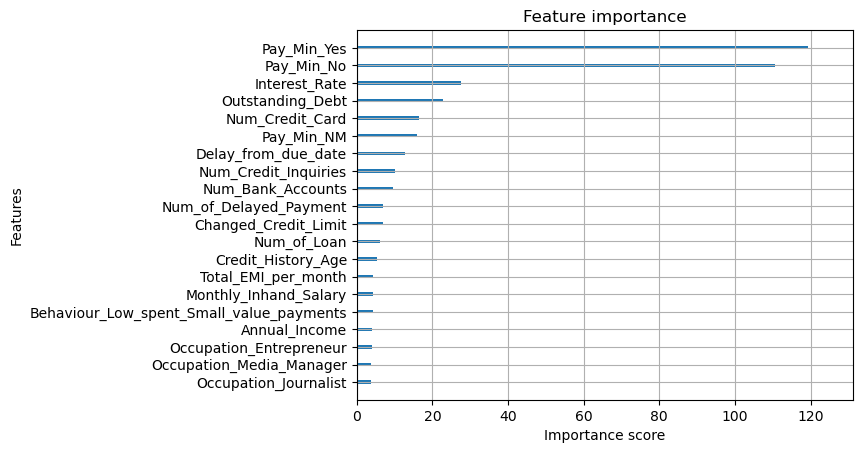

In [7]:
plot_importance(model, max_num_features=20, importance_type='gain', show_values=False);

### <font color = 'skyblue'> Shap Values

In [8]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

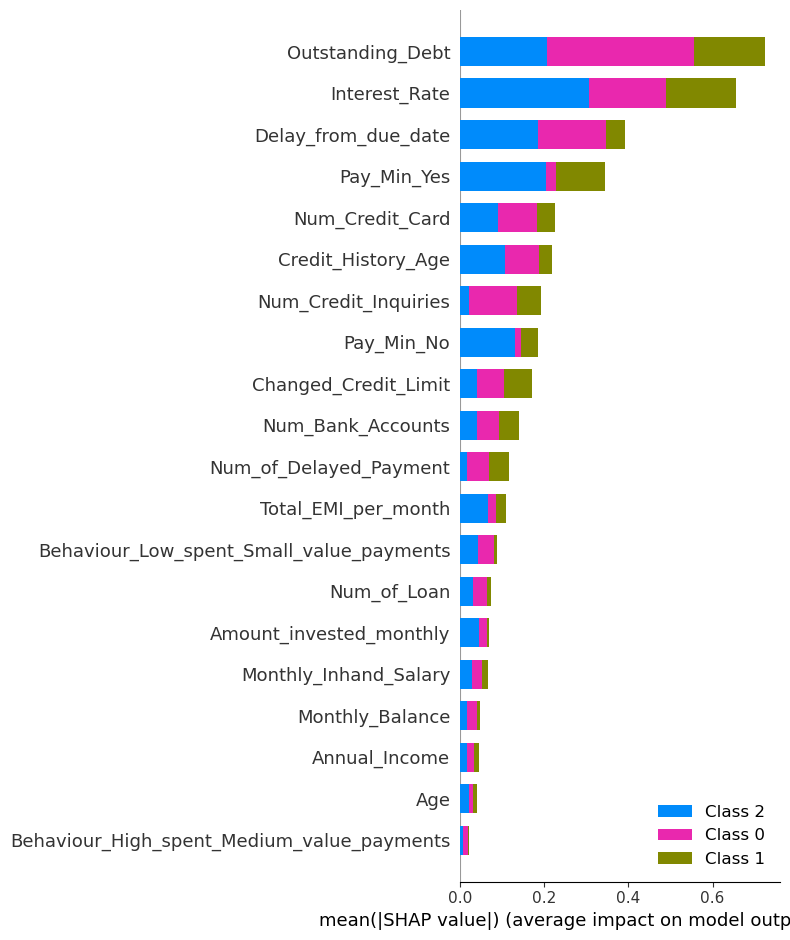

In [9]:
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20)

In [10]:
print("Verificando estructura de SHAP values...")
print(f"Tipo: {type(shap_values)}")

if isinstance(shap_values, list):
    print(f"Número de clases: {len(shap_values)}")
    print(f"Shape de cada clase: {shap_values[0].shape}")
    # Ya está en el formato correcto
    
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    print(f"Shape original: {shap_values.shape}")
    # Convertir a lista de arrays (transponer)
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    print(f"Convertido a lista de {len(shap_values)} arrays")
    print(f"Shape de cada clase: {shap_values[0].shape}")

Verificando estructura de SHAP values...
Tipo: <class 'numpy.ndarray'>
Shape original: (20000, 52, 3)
Convertido a lista de 3 arrays
Shape de cada clase: (20000, 52)


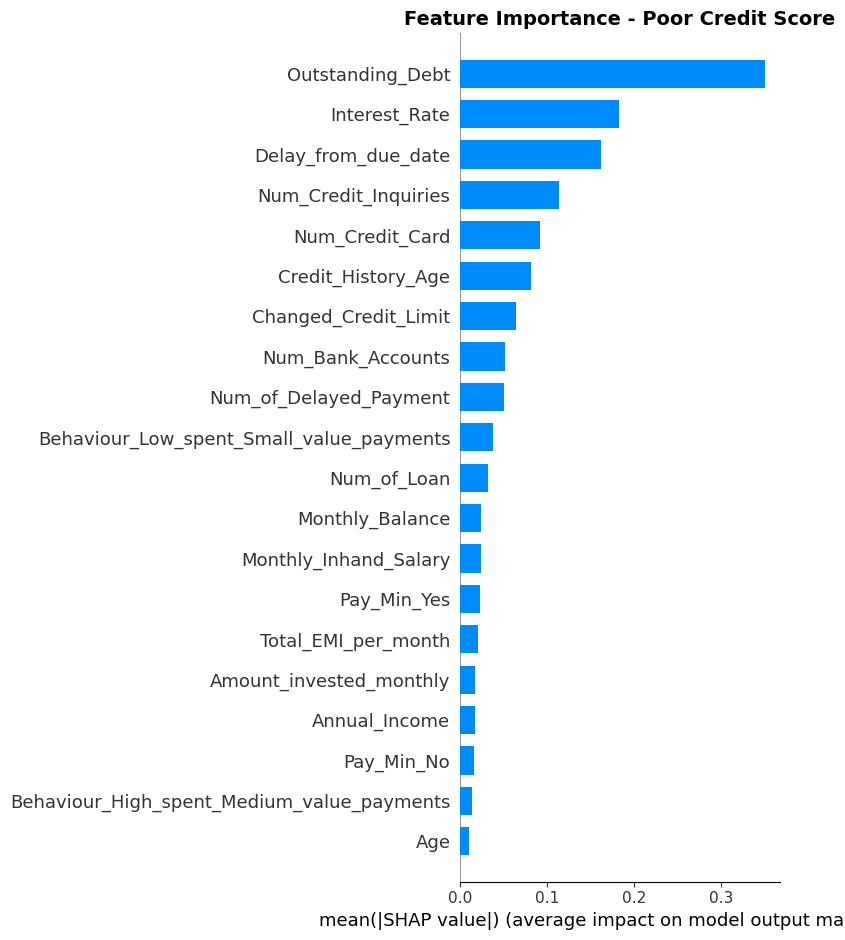

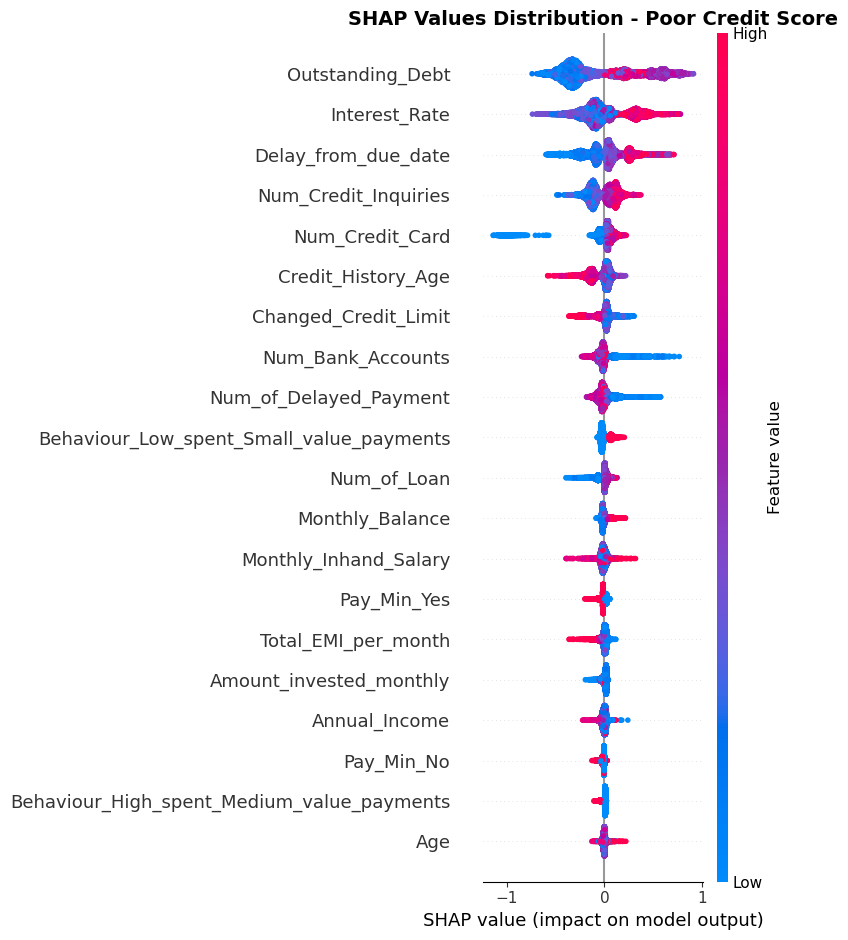

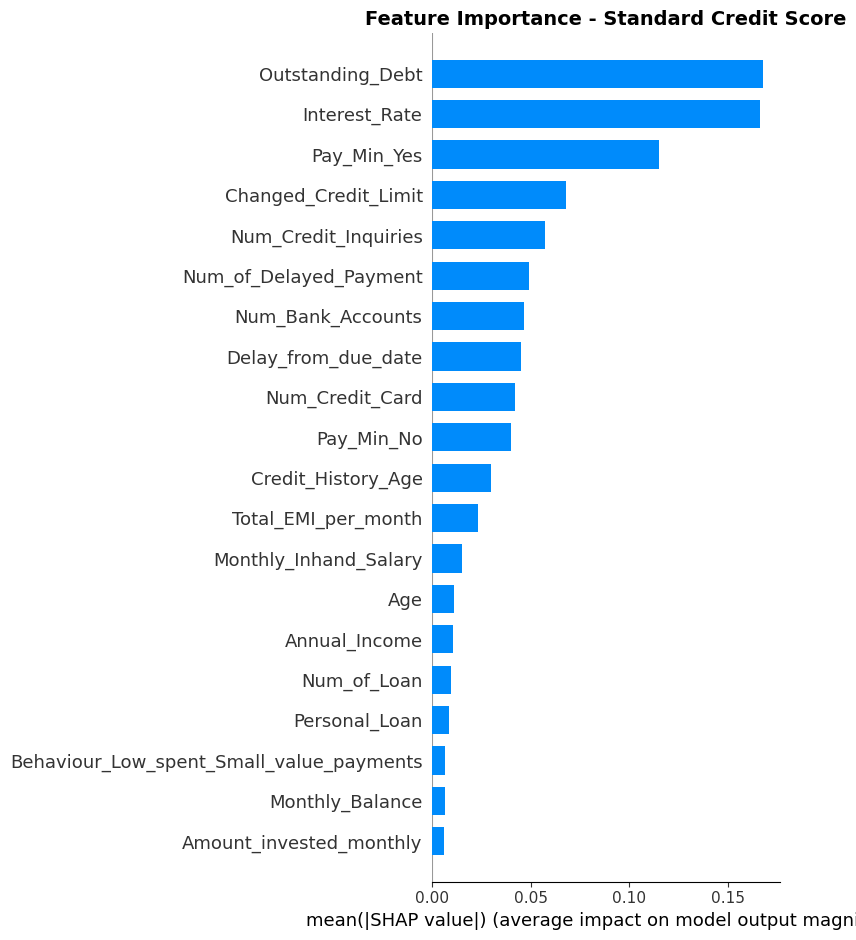

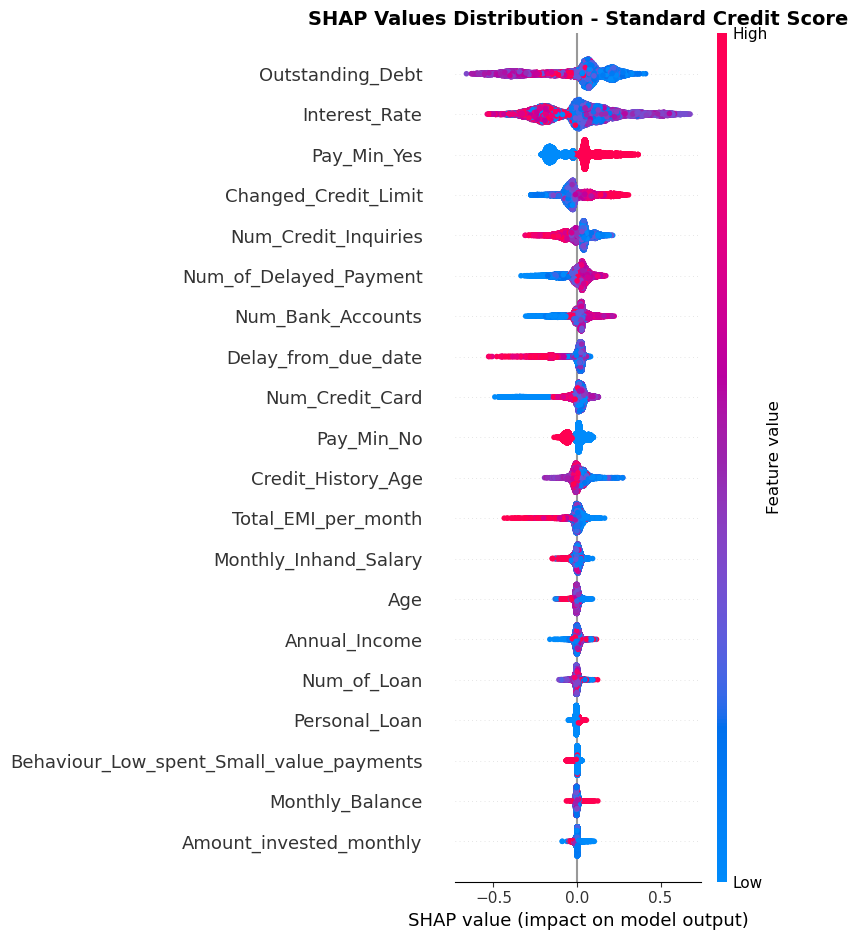

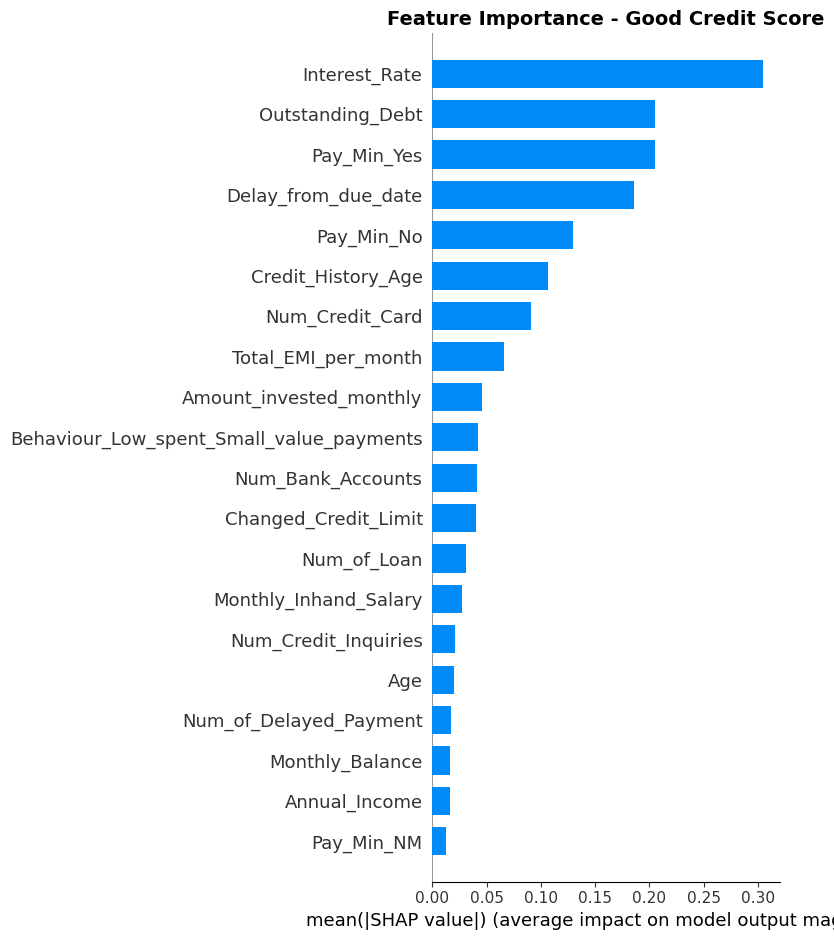

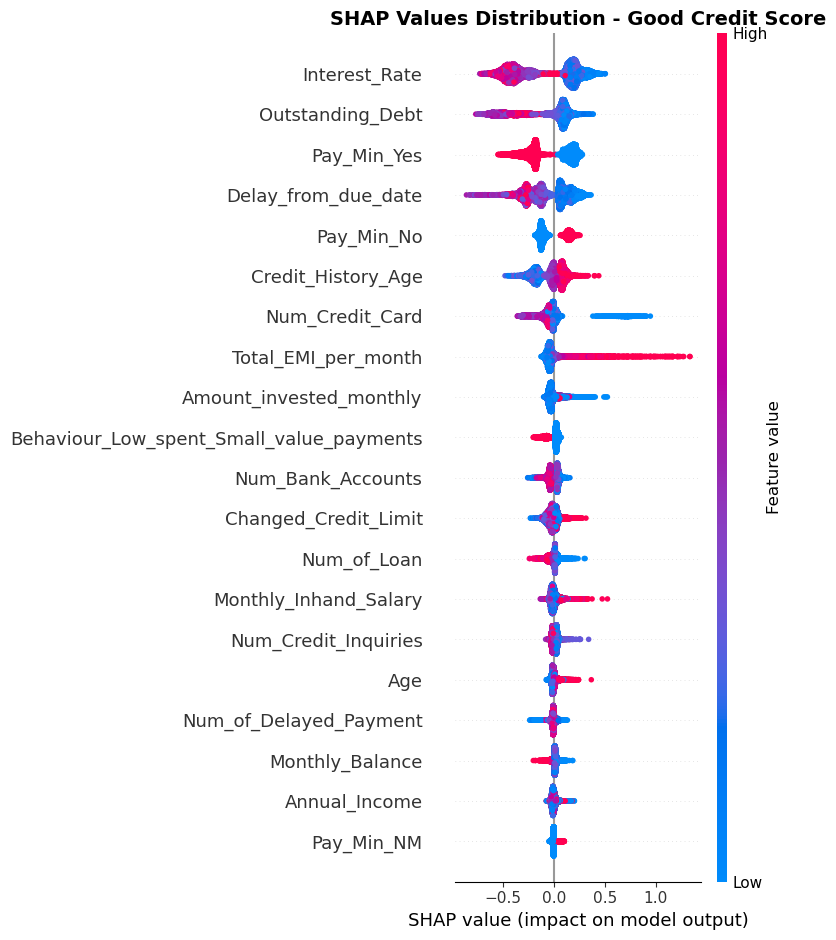

In [11]:
class_names = ['Poor', 'Standard', 'Good']

for i, class_name in enumerate(class_names):
    
    # Bar plot: importancia absoluta
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values[i], 
                     X_test,
                     plot_type="bar",
                     max_display=20,
                     show=False)
    plt.title(f'Feature Importance - {class_name} Credit Score', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Beeswarm plot: dirección del efecto
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values[i], 
                     X_test,
                     max_display=20,
                     show=False)
    plt.title(f'SHAP Values Distribution - {class_name} Credit Score', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### <font color = 'skyblue'> Selected Features

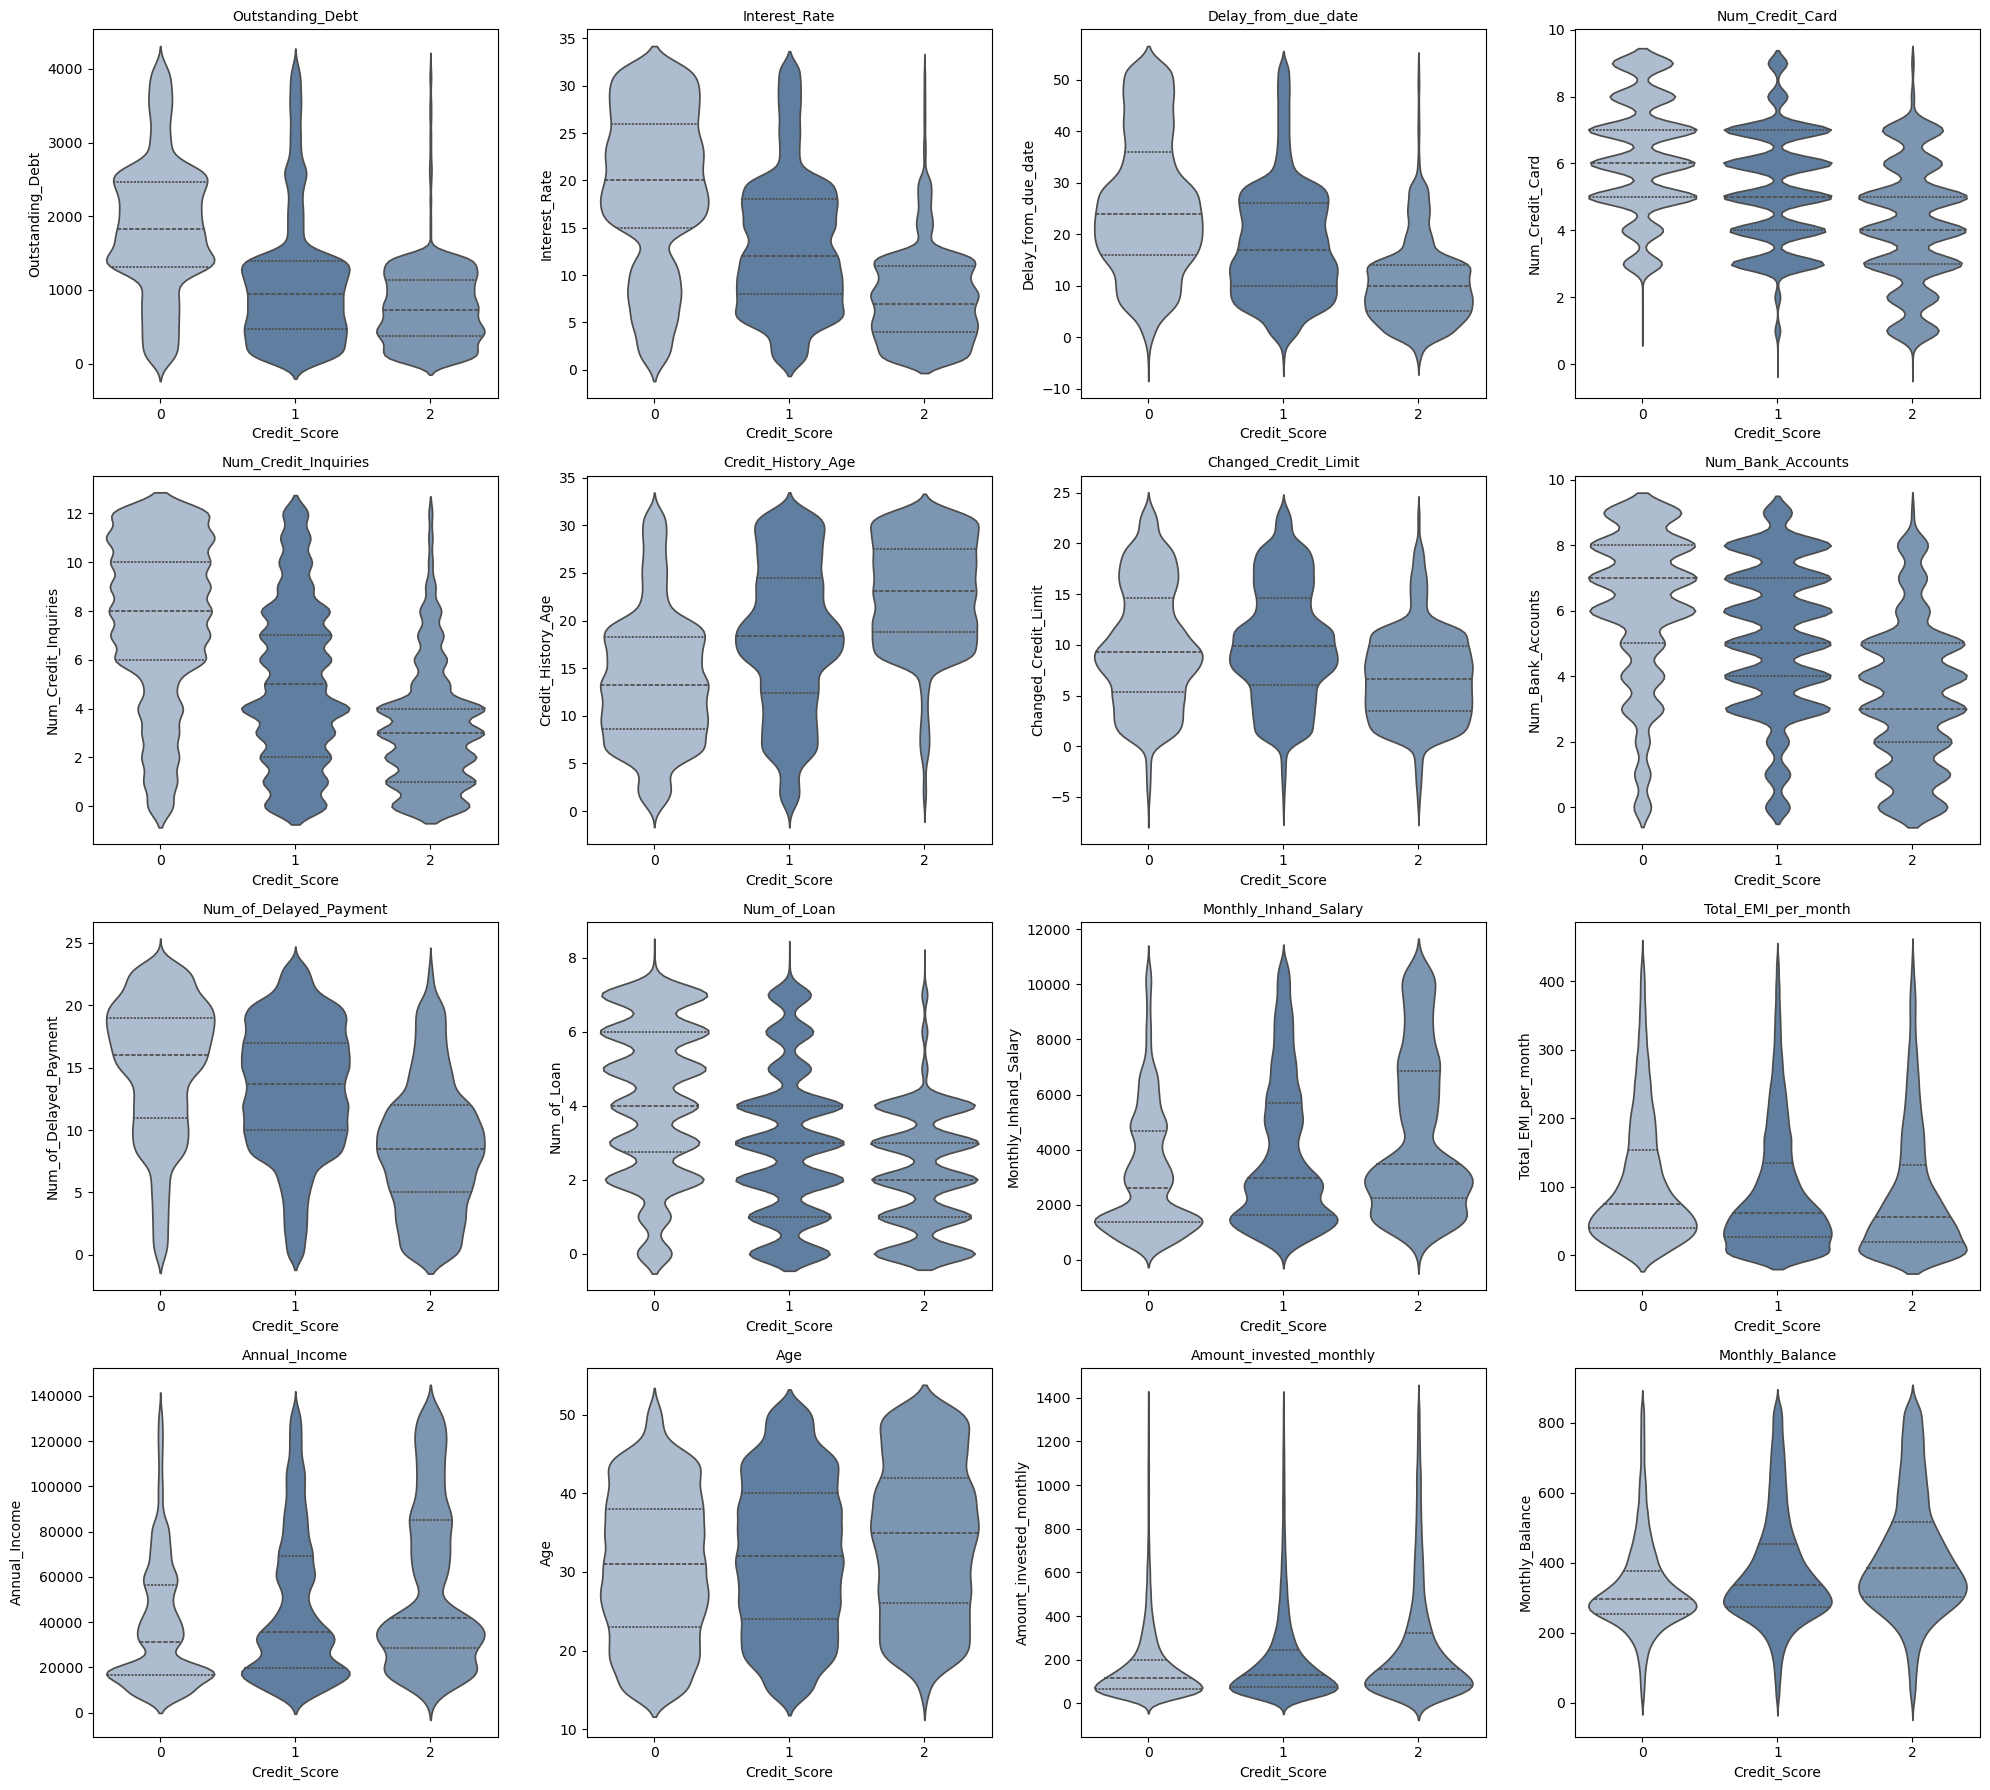

In [12]:
color_palette = ['#A7BCD4', '#547DAB', '#7394BA']

# To select the variables first we filter the top 20 most important features based on feature importance, shap values in general and shap values for people with 
# poor credit score (we consider more important to detect people with poor credit score given the default risk), then we pick the ones that appear in 2 out of 3.
variables = [
    'Outstanding_Debt',
    'Interest_Rate',
    'Delay_from_due_date',
    'Num_Credit_Card',
    'Num_Credit_Inquiries',
    'Credit_History_Age',
    'Changed_Credit_Limit',
    'Num_Bank_Accounts',
    'Num_of_Delayed_Payment',
    'Num_of_Loan',
    'Monthly_Inhand_Salary',
    'Total_EMI_per_month',
    'Annual_Income',
    'Age',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

n_cols = 4
n_rows = int(np.ceil(len(variables) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 18))
axes = axes.flatten()

# We filter by the 95th percentile to avoid outliers distorting the plots, but we keep all the data for the analysis. We look for clear patterns in the data distribution.
for i, var in enumerate(variables):
    
    data_filtered = data[data[var] < data[var].quantile(0.95)]
    
    sns.violinplot(
        data=data_filtered,
        x='Credit_Score',
        y=var,
        common_norm=False,
        inner='quartile',
        ax=axes[i],
        palette=color_palette
    )
    
    axes[i].set_title(var, fontsize=10)
    axes[i].tick_params(axis='x', rotation=0)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## <font color='royalblue'> Weights 

In [13]:
# We keep 3 binary varibles based on importance, and 10 numerical variables that appear in at least 2 out of 3 importance lists 
# (feature importance, shap values overall and shap values for poor credit score) and showed clear patterns between group distributions in the violin plots.
final_variables = [
    'Outstanding_Debt',
    'Interest_Rate',
    'Delay_from_due_date',
    'Num_Credit_Card',
    'Num_Credit_Inquiries',
    'Credit_History_Age',
    'Num_Bank_Accounts',
    'Num_of_Delayed_Payment',
    'Monthly_Inhand_Salary',
    'Age',
    'Pay_Min_Yes',
    'Pay_Min_No',
    'Behaviour_High_spent_Medium_value_payments'
]

variables_importances_xgboost = pd.DataFrame({
    'feature': X.columns,
    'importance_xgboost': model.feature_importances_,
}).sort_values(by='importance_xgboost', ascending=False)

# An easy way to estbalish proper weights for the variables is to just take the importance values from the xgboost model given its very high accuracy.
var_final = (variables_importances_xgboost
             .set_index('feature')
             .loc[final_variables])

var_final

,importance_xgboost
feature,
Outstanding_Debt,0.045688
Interest_Rate,0.054966
Delay_from_due_date,0.025402
Num_Credit_Card,0.032896
Num_Credit_Inquiries,0.020056
Credit_History_Age,0.010856
Num_Bank_Accounts,0.019236
Num_of_Delayed_Payment,0.014011
Monthly_Inhand_Salary,0.008565


In [14]:
# We invert the sign of the variables that have a negative relationship with the credit score to make the interpretation easier, so higher values always mean higher credit score.
negative_relationships = ['Outstanding_Debt', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Card', 'Num_Credit_Inquiries', 'Num_Bank_Accounts', 'Num_of_Delayed_Payment']

for var in negative_relationships:
    var_final.loc[var] = -var_final.loc[var]

weights = var_final['importance_xgboost']

## <font color='royalblue'> Scores 

In [15]:
# Filter tha dataframe to keep only the final variables and the target variable.
data_for_model = data[final_variables + ['Credit_Score']]
# Calculate the credit score as a weighted sum of the final variables using the importance values from the xgboost model as weights.
data_for_model['Score'] = np.dot(data_for_model[final_variables], weights)
data_for_model

,Outstanding_Debt,Interest_Rate,Delay_from_due_date,Num_Credit_Card,Num_Credit_Inquiries,Credit_History_Age,Num_Bank_Accounts,Num_of_Delayed_Payment,Monthly_Inhand_Salary,Age,Pay_Min_Yes,Pay_Min_No,Behaviour_High_spent_Medium_value_payments,Credit_Score,Score
0,809.98,3.0,3.0,4.0,4.0,22.083333,3.0,7.000000,1824.843333,23.000000,False,True,False,2,-21.36755
1,809.98,3.0,-1.0,4.0,4.0,22.166667,3.0,7.622611,1824.843333,23.000000,False,True,False,2,-21.273762
2,809.98,3.0,3.0,4.0,4.0,22.250000,3.0,7.000000,1824.843333,46.072142,False,True,False,2,-21.207884
3,809.98,3.0,5.0,4.0,4.0,22.333333,3.0,4.000000,1824.843333,23.000000,False,True,False,2,-21.373607
4,809.98,3.0,6.0,4.0,4.0,22.416667,3.0,7.310352,1824.843333,23.000000,False,True,True,2,-21.438058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,502.38,7.0,23.0,6.0,3.0,31.500000,4.0,7.000000,3359.415833,25.000000,False,True,False,0,5.152298
99996,502.38,7.0,18.0,6.0,3.0,31.583333,4.0,7.000000,3359.415833,25.000000,False,True,True,0,5.286636
99997,502.38,5729.0,27.0,6.0,3.0,31.666667,4.0,6.000000,3359.415833,25.000000,False,True,False,0,-309.449809
99998,502.38,7.0,20.0,6.0,3.0,31.750000,4.0,12.724599,3359.415833,25.000000,False,True,False,1,5.151011


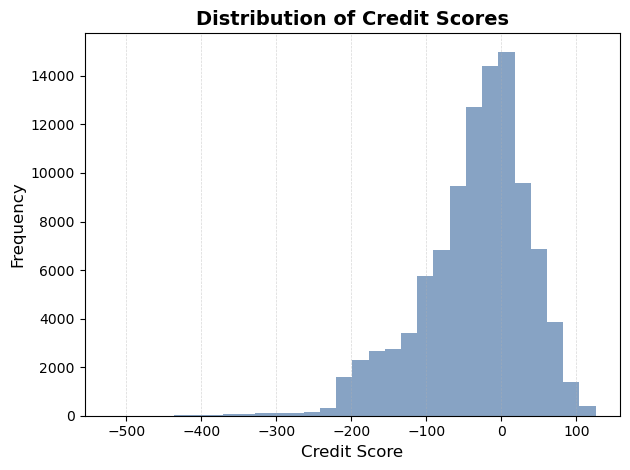

 Min Credit Score: -523.11
 Max Credit Score: 125.60


In [16]:
plt.hist(data_for_model['Score'], bins=30, color='#547DAB', alpha=0.7)
plt.title('Distribution of Credit Scores', fontsize=14, fontweight='bold')
plt.xlabel('Credit Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.grid(axis='x', alpha=0.5, linestyle='--', linewidth=0.5)
plt.show()

print(f' Min Credit Score: {data_for_model["Score"].min():.2f}')
print(f' Max Credit Score: {data_for_model["Score"].max():.2f}')

## <font color='royalblue'> Optimizing Thresholds 

In [17]:
# Filter the datafrae with the mdoel variables into train and test sets to evaluate the performance of the credit score as a predictor of the credit score groups.
train_results = data_for_model.loc[X_train.index]
test_results = data_for_model.loc[X_test.index]

In [18]:
scores = test_results['Score'].values
true_labels = test_results['Credit_Score'].values

min_score = scores.min()
max_score = scores.max()

def objective(trial):
    
    t1 = trial.suggest_int("t1", min_score, max_score)
    t2 = trial.suggest_int("t2", t1, max_score)
    
    preds = np.where(scores < t1, 0,
             np.where(scores < t2, 1, 2))
    
    acc = (preds == true_labels).mean()
    
    return acc

study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=300,
    show_progress_bar=True,

)

print("Best thresholds:", study.best_params)
print("Best accuracy:", study.best_value)

  0%|          | 0/300 [00:00<?, ?it/s]

Best thresholds: {'t1': -52, 't2': 110}
Best accuracy: 0.58705


In [19]:
# Map the calculated score to the original classification (0,1,2) in order to compute relevant classification metrics
t1 = study.best_params['t1']
t2 = study.best_params['t2']
    
test_results['Calculated_Score'] = test_results['Score'].apply(lambda x: 0 if x < t1 else (1 if x < t2 else 2))
test_results

,Outstanding_Debt,Interest_Rate,Delay_from_due_date,Num_Credit_Card,Num_Credit_Inquiries,Credit_History_Age,Num_Bank_Accounts,Num_of_Delayed_Payment,Monthly_Inhand_Salary,Age,Pay_Min_Yes,Pay_Min_No,Behaviour_High_spent_Medium_value_payments,Credit_Score,Score,Calculated_Score
29322,4598.36,31.0,17.0,8.0,12.0,6.000000,10.0,21.000000,686.556667,31.0,True,False,False,1,-206.819255,0
23872,1305.65,1.0,10.0,6.0,4.0,19.750000,5.0,5.000000,6016.678333,51.0,False,True,False,1,-8.089429,1
59885,1485.60,26.0,32.0,10.0,12.0,6.500000,7.0,17.000000,5777.193333,22.0,True,False,False,0,-21.118474,1
54432,2697.61,23.0,54.0,8.0,6.0,5.333333,7.0,22.000000,1689.310000,30.0,True,False,True,1,-111.733619,0
47864,1311.23,21.0,49.0,5.0,9.0,12.583333,7.0,24.000000,493.603333,45.0,True,False,False,0,-58.211596,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13701,777.97,8.0,9.0,7.0,1.0,31.750000,5.0,7.000000,6168.063333,38.0,False,True,False,1,16.996889,1
9600,1048.34,2.0,12.0,836.0,3.0,32.916667,2.0,8.000000,2928.822500,54.0,False,True,True,2,-49.984004,1
98795,1166.37,11.0,12.0,7.0,5.0,20.583333,7.0,11.178765,5463.165000,40.0,True,False,False,1,-7.293941,1
95452,4726.13,34.0,19.0,5.0,7.0,2.500000,6.0,15.000000,6753.243333,42.0,True,False,True,1,-160.509101,0


In [20]:
# Comparing original class distribution against the predicted one
test_results['Credit_Score'].value_counts()
percentages = test_results['Credit_Score'].value_counts(normalize=True) * 100

test_results['Calculated_Score'].value_counts()
percentages_calculated = test_results['Calculated_Score'].value_counts(normalize=True) * 100

print("\nOriginal Distribution:")
print("-" * 30)
for label, pct in percentages.sort_index().items():
    print(f"  Class {label}: {pct:>6.2f}%")

print("\nPredicted Distribution:")
print("-" * 30)
for label, pct in percentages_calculated.sort_index().items():
    print(f"  Class {label}: {pct:>6.2f}%")


Original Distribution:
------------------------------
  Class 0:  28.99%
  Class 1:  53.17%
  Class 2:  17.83%

Predicted Distribution:
------------------------------
  Class 0:  33.17%
  Class 1:  66.61%
  Class 2:   0.22%


              precision    recall  f1-score   support

           0       0.57      0.65      0.60      5799
           1       0.60      0.75      0.67     10635
           2       0.45      0.01      0.01      3566

    accuracy                           0.59     20000
   macro avg       0.54      0.47      0.43     20000
weighted avg       0.56      0.59      0.53     20000



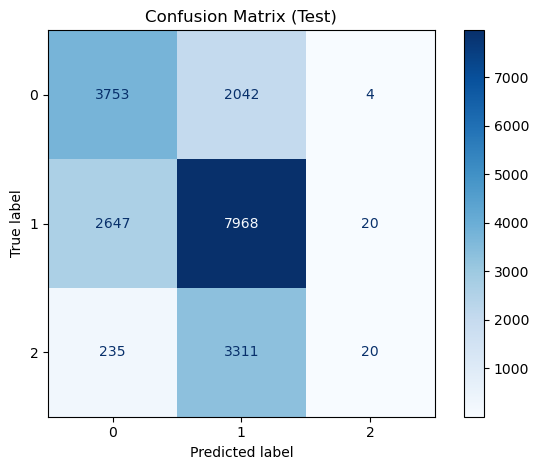

In [21]:
# Evaluation
print(classification_report(test_results['Credit_Score'], test_results['Calculated_Score']))

ConfusionMatrixDisplay.from_predictions(
    test_results['Credit_Score'], test_results['Calculated_Score'],
    display_labels=[0, 1, 2],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

### <font color = 'skyblue'> Balancing Classes

In [22]:
scores = test_results['Score'].values
true_labels = test_results['Credit_Score'].values

min_score = scores.min()
max_score = scores.max()

# Calculate true class distribution
true_dist = pd.Series(true_labels).value_counts(normalize=True).sort_index()
print("True class distribution:")
print(true_dist)

def objective(trial):
    
    t1 = trial.suggest_int("t1", min_score, max_score)
    t2 = trial.suggest_int("t2", t1, max_score)
    
    preds = np.where(scores < t1, 0,
             np.where(scores < t2, 1, 2))
    
    # Calculate predicted class distribution
    pred_dist = pd.Series(preds).value_counts(normalize=True).sort_index()
    
    if len(pred_dist) < 3:
        return 0.0
    
    # Calculate class balance penalty (distance between distributions)
    balance_penalty = np.abs(pred_dist.values - true_dist.values).sum()
    
    # Considering original class distribution we restrict to anwers between 15% to 60% for each class
    for class_label in [0, 1, 2]:
        class_proportion = (preds == class_label).mean()
        if class_proportion < 0.15 or class_proportion > 0.60:
            return 0.0
    
    # Calculate recall for each class (how many trues per class we correctly classify)
    class_recalls = []
    for class_label in [0, 1, 2]:
        true_as_class = (true_labels == class_label)
        if true_as_class.sum() == 0:
            continue
        
        correct = ((preds == class_label) & (true_labels == class_label)).sum()
        recall = correct / true_as_class.sum()
        class_recalls.append(recall)
    
    balanced_recall = np.mean(class_recalls)
    
    # Maximize our mean recall while penalizing if the predicted distribution is very different from the true distribution
    # This parts help us having a more balanced model that avoids making everyone the majority class
    objective_value = balanced_recall - (0.5 * balance_penalty)
    
    return objective_value

study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=500,
    show_progress_bar=True,
)

print("Best thresholds:", study.best_params)
print("Best objective value:", study.best_value)

True class distribution:
0    0.28995
1    0.53175
2    0.17830
Name: proportion, dtype: float64


  0%|          | 0/500 [00:00<?, ?it/s]

Best thresholds: {'t1': -59, 't2': 26}
Best objective value: 0.4897918578457671


In [23]:
# Map the calculated score to the original classification (0,1,2) in order to compute relevant classification metrics
t1_balanced = study.best_params['t1']
t2_balanced = study.best_params['t2']
    
test_results['Calculated_Score'] = test_results['Score'].apply(lambda x: 0 if x < t1 else (1 if x < t2 else 2))
test_results

,Outstanding_Debt,Interest_Rate,Delay_from_due_date,Num_Credit_Card,Num_Credit_Inquiries,Credit_History_Age,Num_Bank_Accounts,Num_of_Delayed_Payment,Monthly_Inhand_Salary,Age,Pay_Min_Yes,Pay_Min_No,Behaviour_High_spent_Medium_value_payments,Credit_Score,Score,Calculated_Score
29322,4598.36,31.0,17.0,8.0,12.0,6.000000,10.0,21.000000,686.556667,31.0,True,False,False,1,-206.819255,0
23872,1305.65,1.0,10.0,6.0,4.0,19.750000,5.0,5.000000,6016.678333,51.0,False,True,False,1,-8.089429,1
59885,1485.60,26.0,32.0,10.0,12.0,6.500000,7.0,17.000000,5777.193333,22.0,True,False,False,0,-21.118474,1
54432,2697.61,23.0,54.0,8.0,6.0,5.333333,7.0,22.000000,1689.310000,30.0,True,False,True,1,-111.733619,0
47864,1311.23,21.0,49.0,5.0,9.0,12.583333,7.0,24.000000,493.603333,45.0,True,False,False,0,-58.211596,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13701,777.97,8.0,9.0,7.0,1.0,31.750000,5.0,7.000000,6168.063333,38.0,False,True,False,1,16.996889,1
9600,1048.34,2.0,12.0,836.0,3.0,32.916667,2.0,8.000000,2928.822500,54.0,False,True,True,2,-49.984004,1
98795,1166.37,11.0,12.0,7.0,5.0,20.583333,7.0,11.178765,5463.165000,40.0,True,False,False,1,-7.293941,1
95452,4726.13,34.0,19.0,5.0,7.0,2.500000,6.0,15.000000,6753.243333,42.0,True,False,True,1,-160.509101,0


In [24]:
# Comparing original class distribution against the predicted one
test_results['Credit_Score'].value_counts()
percentages = test_results['Credit_Score'].value_counts(normalize=True) * 100

test_results['Calculated_Score'].value_counts()
percentages_calculated = test_results['Calculated_Score'].value_counts(normalize=True) * 100

print("\nOriginal Distribution:")
print("-" * 30)
for label, pct in percentages.sort_index().items():
    print(f"  Class {label}: {pct:>6.2f}%")

print("\nPredicted Distribution:")
print("-" * 30)
for label, pct in percentages_calculated.sort_index().items():
    print(f"  Class {label}: {pct:>6.2f}%")


Original Distribution:
------------------------------
  Class 0:  28.99%
  Class 1:  53.17%
  Class 2:  17.83%

Predicted Distribution:
------------------------------
  Class 0:  33.17%
  Class 1:  66.61%
  Class 2:   0.22%


              precision    recall  f1-score   support

           0       0.57      0.65      0.60      5799
           1       0.60      0.75      0.67     10635
           2       0.45      0.01      0.01      3566

    accuracy                           0.59     20000
   macro avg       0.54      0.47      0.43     20000
weighted avg       0.56      0.59      0.53     20000



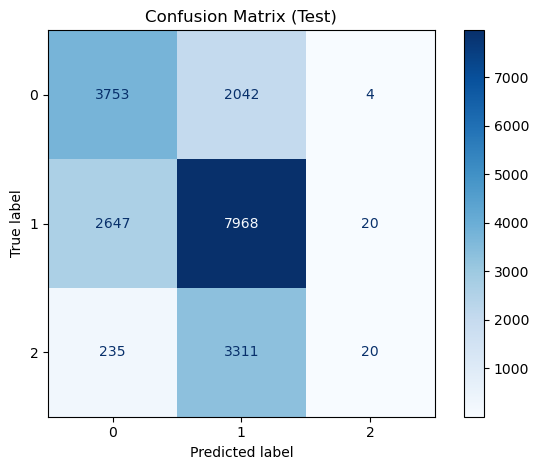

In [25]:
# Evaluation
print(classification_report(test_results['Credit_Score'], test_results['Calculated_Score']))

ConfusionMatrixDisplay.from_predictions(
    test_results['Credit_Score'], test_results['Calculated_Score'],
    display_labels=[0, 1, 2],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

## <font color='royalblue'> Results